In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_LncRNA_identificados.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df = df.loc[:, ~df.columns.str.contains('Raw')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df = df.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T

Como hay tantas variables, procedemos a descartar aquellas que sean redundantes

## Reducción de dimensionalidad

### Lecturas bajas

Consideramos variables con lectuas bajas aquellas que tengan una frecuencia mayor del 50% con lecturas de menor de un threshold:

In [4]:
for thres in [0.1,0.2,0.3,0.5,0.6,0.7,0.8,0.9]:
    estadisticas = pd.DataFrame({
    'NoCeros': (df != 0).sum(),
    'CercanoCero': (df < thres).sum(),
    'Porcentaje de lencturas cercanas a cero' : (df < thres).sum()/35,
    'Media': df.mean(),
    'Desviación': df.std(),
    'Suma total': df.sum(),
    'Maximo' : df.max(),
    'Minimo' : df.min()
    })

    print(f'Lecturas menores de {thres} con una frecuencia de más del 50% hay', len(estadisticas[estadisticas['Porcentaje de lencturas cercanas a cero'] > 0.5]),'variables')

Lecturas menores de 0.1 con una frecuencia de más del 50% hay 0 variables
Lecturas menores de 0.2 con una frecuencia de más del 50% hay 1 variables
Lecturas menores de 0.3 con una frecuencia de más del 50% hay 3 variables
Lecturas menores de 0.5 con una frecuencia de más del 50% hay 10 variables
Lecturas menores de 0.6 con una frecuencia de más del 50% hay 16 variables
Lecturas menores de 0.7 con una frecuencia de más del 50% hay 37 variables
Lecturas menores de 0.8 con una frecuencia de más del 50% hay 67 variables
Lecturas menores de 0.9 con una frecuencia de más del 50% hay 95 variables


Se elige 0.6

In [5]:
thres_elegido = 0.6

estadisticas = pd.DataFrame({
    'NoCeros': (df != 0).sum(),
    'CercanoCero': (df < 0.5).sum(),
    'Porcentaje de lencturas cercanas a cero' : (df < thres_elegido).sum()/35,
    'Media': df.mean(),
    'Desviación': df.std(),
    'Suma total': df.sum(),
    'Maximo' : df.max(),
    'Minimo' : df.min()
    }).sort_values('Porcentaje de lencturas cercanas a cero', ascending = False)
vars_est = estadisticas[estadisticas['Porcentaje de lencturas cercanas a cero'] > 0.5]
vars_est

,NoCeros,CercanoCero,Porcentaje de lencturas cercanas a cero,Media,Desviación,Suma total,Maximo,Minimo
hgnc_symbol,,,,,,,,
DNAAF4-CCPG1,35,27,0.800000,0.407633,0.687793,14.267146,2.909775,0.011532
LYPLAL1-AS1,35,23,0.714286,0.530408,0.425495,18.564288,1.953195,0.014390
LINC00865,35,25,0.714286,0.665514,0.785052,23.292979,3.530602,0.052633
LINC02388,35,21,0.685714,0.840344,1.071354,29.412056,3.792128,0.015304
LINC01697,35,22,0.685714,0.716995,0.951829,25.094813,3.921769,0.018421
LINC02506,35,21,0.657143,0.974187,1.751366,34.096542,7.400966,0.011532
LINC02160,35,21,0.657143,0.621431,0.468060,21.750100,1.830866,0.046138
LINC02427,35,17,0.600000,0.572845,0.359135,20.049577,1.340731,0.056041
LINC02804,35,21,0.600000,0.536994,0.479179,18.794805,1.704988,0.043169


In [6]:
vars_excluir = vars_est.reset_index()['hgnc_symbol'].to_list()
df1 = df.drop(columns=vars_excluir)

print(len(df.columns),'variables →',len(df1.columns),'variables')

695 variables → 679 variables


### Correlaciones

La correlación de Spearman no elimina ninguna variable ya que de acuerdo con ella, no hay ninguna correlación a un threshold > 0.95

In [7]:
df_list = []
threshold = 0.8
correlaciones_vars = df1.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df1.columns)        
df1 = df1.drop(columns=columns_to_drop)   
print(nvarsAntes,'variables →',len(df1.columns),'variables')

679 variables → 662 variables


### Tests

Se procede a hacer un test para cada variable para determinar si existen diferencias significativas entre el grupo de Tratamiento y Control. Esto nos permitirá saber si cada variable es estadíticamente diferente o no. Las que no son diferentes podemos procederlas a eliminarlas ya que el objetivo de este análisis es determinar las diferencias entre ambos grupos

In [8]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
from statsmodels.stats.multitest import multipletests

In [9]:
####Dividmos el data set en dos: Uno de tratamiento y otro de control

df1_ct = df1.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

In [10]:
variables = df1_ct.columns  
variablesIncluir = []
variablesExcluir = []
p_values = []
tests = []  # Para almacenar qué test se usó en cada variable

for var in variables:
    # Prueba de normalidad en ambos grupos
    p_value_trnto = shapiro(df1_trnto[var]).pvalue
    p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
    # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
    
    if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
        #Los dos p_values son normales → Usamos T_student
        stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
        test_name = 't-test'
    else:
        # Al menos un grupo no es normal → Usamos Mann-Whitney U
        stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
        test_name = 'Mann-Whitney'

    tests.append(test_name)
    p_values.append(p_value)  # Guardamos el p-valor obtenido

# Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

# Clasificar variables según la corrección FDR
variablesIncluir = [var for var, r in zip(variables, reject) if r]
variablesExcluir = [var for var, r in zip(variables, reject) if not r]

# Guardar los resultados en un DataFrame
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Test aplicado': tests,
    'p-valor original': p_values,
    'p-valor ajustado (FDR)': p_adjusted,
    'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
})

In [11]:
print(len(variables),'→',len(variablesIncluir))

662 → 75


In [12]:
df1 = df1[variablesIncluir]

## Análisis

### Random Forest con todo el data set

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from tqdm import tqdm 
import pickle

In [ ]:
scaler = StandardScaler()
df_scaled  = scaler.fit_transform(df1)
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)
df_scaled = df_scaled.set_index(df1.index)
df_scaled2 = df_scaled.copy()
df_scaled2 = df_scaled2.reset_index()
df_scaled2['Grupo'] = np.where(df_scaled2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled2['index'].str.contains('C'), 'Control', 'Otro'))
df_scaled2 = df_scaled2.set_index('index')
df_scaled2 = pd.get_dummies(df_scaled2, columns=['Grupo'], drop_first=True)
df_scaled2['Grupo_Tratamiento'] = df_scaled2['Grupo_Tratamiento'].astype(int)

#### Bootstrap

In [44]:
X = df_scaled2.drop(columns=[ "Grupo_Tratamiento"])  
y = df_scaled2["Grupo_Tratamiento"]
n_iteraciones = 5000
max_depth_options = list(range(3, 10))
min_samples_split_options = list(range(2, 30))
min_samples_leaf_options = list(range(1, 15))
n_estimators_options = list(range(1,200))
criterions = ['gini', 'entropy']
resultados = []

for i in tqdm(range(n_iteraciones), desc="Iterando modelos"):
    ##BOOTSTRAP
    sample_indices = np.random.choice(range(len(X)), size=len(X), replace=True)
    X_train = X.iloc[sample_indices]
    y_train = y.iloc[sample_indices]
    test_mask = ~np.isin(range(len(X)), sample_indices)
    X_test = X.iloc[test_mask]
    y_test = y.iloc[test_mask]

    # Hiperparámetros aleatorios
    n_estimators = random.choice(n_estimators_options)
    max_depth = random.choice(max_depth_options)
    min_samples_split = random.choice(min_samples_split_options)
    min_samples_leaf = random.choice(min_samples_leaf_options)
    criterion = random.choice(criterions)

    #Modelo
    rf  = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random.choice(list(range(1,100000000)))
    )
    rf.fit(X_train, y_train)
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    important_features = []
    for idx, f in enumerate(X.columns):
        importance = rf.feature_importances_[idx]
        if importance > 0:
            important_features.append((f, importance))
    if important_features:
        for feature, importance in important_features:
            resultados.append({
                'Iteration': i,
                'Feature': feature,
                'Importance': importance,
                'Train Accuracy': train_accuracy,
                'Test Accuracy': test_accuracy
            })

# Crear un DataFrame con los resultados
df_results = pd.DataFrame(resultados)

Iterando modelos:   0%|          | 0/5000 [00:00<?, ?it/s]

Iterando modelos: 100%|██████████| 5000/5000 [8:08:51<00:00,  5.87s/it]   


In [45]:
df_results = pd.DataFrame(resultados)
df_results.to_csv('../WorkingFiles/LncRNA_BootstrapRFDec.csv',index = False)

In [66]:
df_results = pd.read_csv('../WorkingFiles/LncRNA_BootstrapRFDec.csv')
temp_df = df_results.groupby('Feature').agg(
    Conteo=('Feature', 'count'),
    Promedio_Importancia=('Importance', 'mean'),
    Promedio_Train_accuracy=('Train Accuracy','mean'),
    Promedio_Test_accuracy=('Test Accuracy','mean')
).reset_index()

# Calcular porcentaje sobre el total
temp_df['Frecuencia'] = temp_df['Conteo'] / 5000

# Ordenar por porcentaje y promedio de importancia
mostImpFeaturesTree = temp_df.sort_values(by=['Frecuencia', 'Promedio_Importancia'], ascending=False)
mostImpFeaturesTree = mostImpFeaturesTree[['Feature', 'Conteo', 'Frecuencia','Promedio_Importancia', 'Promedio_Train_accuracy',
    'Promedio_Test_accuracy']]
threshold_frec = 0.3
mostImpFeaturesTree = mostImpFeaturesTree[mostImpFeaturesTree['Frecuencia'] >threshold_frec].reset_index(drop=True)
mostImpFeaturesTree

,Feature,Conteo,Frecuencia,Promedio_Importancia,Promedio_Train_accuracy,Promedio_Test_accuracy
0,LINC02208,3014,0.6028,0.062468,0.953939,0.848354
1,ARRDC3-AS1,2920,0.5840,0.061404,0.953865,0.849624
2,DIO3OS,2740,0.5480,0.055748,0.956861,0.852778
3,LINC01569,2740,0.5480,0.052349,0.950865,0.847330
4,LINC00964,2599,0.5198,0.050887,0.958918,0.855400
5,OSER1-DT,2599,0.5198,0.046487,0.955137,0.847732
6,LINC01278,2552,0.5104,0.046445,0.958453,0.855856
7,CEROX1,2423,0.4846,0.042221,0.958528,0.849534
8,SNHG19,2333,0.4666,0.043221,0.963260,0.862802
9,LINC02254,2319,0.4638,0.042142,0.961782,0.854751


### Creación de data frames

#### Clustering de variables

Vamos a trasponer el data set al tener más variables que observaciones y le hacemos un clustering. Al hacer esto, el algoritmo nos dirá qué conjuntos de variables son más semejantes entre sí para agruparlas. El resultado sería que se agrupan las variables en diferentes clusters, haciendo así diferentes Data sets con variables similares. 

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:

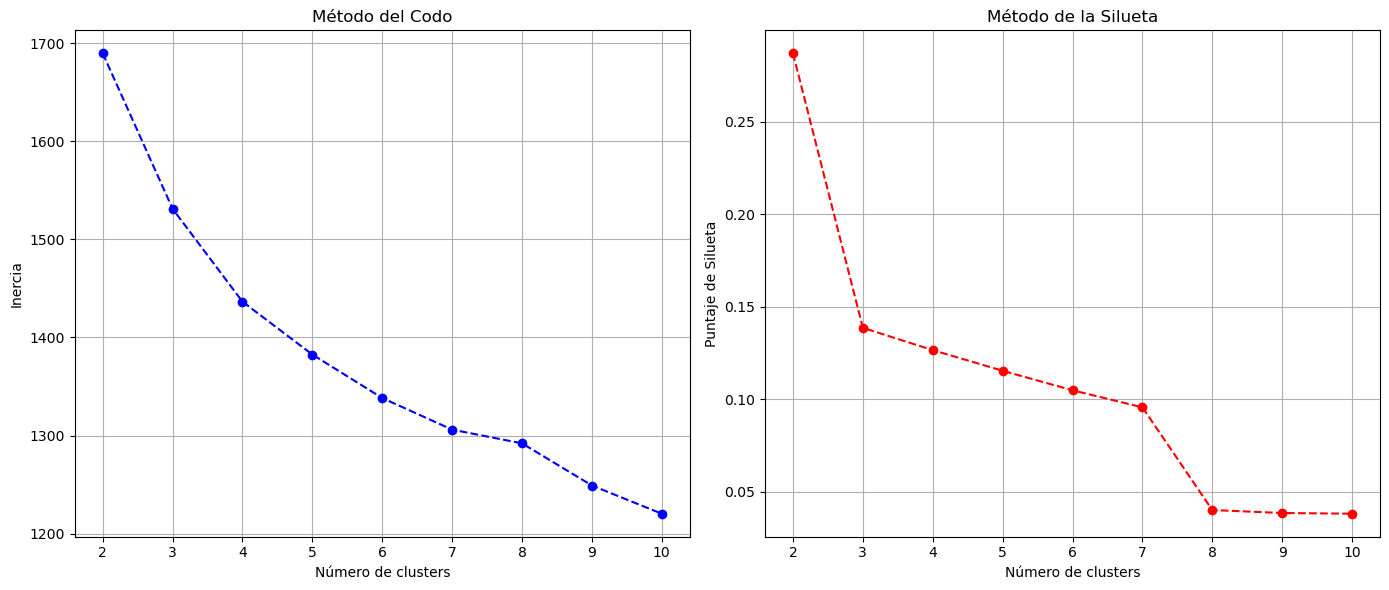

In [21]:
scaler = StandardScaler()
df_scaled  = scaler.fit_transform(df1)
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)
df_scaled = df_scaled.set_index(df1.index)

df_transposed = df_scaled.T 

# Método del Codo
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 11)  # Evaluamos entre 2 y 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_transposed)
    
    # Guardamos la inercia para la técnica del codo
    inertia.append(kmeans.inertia_)
    
    # Calculamos el score de silueta para el método de silueta
    score = silhouette_score(df_transposed, kmeans.labels_)
    silhouette_scores.append(score)

# Gráfico del Método del Codo
plt.figure(figsize=(14, 6))

# Subgráfico para la técnica del codo
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True)

# Subgráfico para el Método de la Silueta
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Método de la Silueta')
plt.xlabel('Número de clusters')
plt.ylabel('Puntaje de Silueta')
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(df_transposed)

# Asignar cada variable a un cluster
clusters = kmeans.labels_
df_transposed['cluster'] = clusters

lista_df_clustersVars = {}
for cluster in range(n_clusters):
    df_cluster = df_transposed[df_transposed['cluster'] == cluster]
    print('DataFrame', cluster,':',len(df_cluster), 'variables')
    lista_df_clustersVars.update({cluster : df_cluster.drop('cluster', axis = 1).T})

DataFrame 0 : 18 variables
DataFrame 1 : 34 variables
DataFrame 2 : 23 variables


c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [24]:
lista_df_clustersVars[0].to_csv('../WorkingFiles/LncRNA_df1.csv')
lista_df_clustersVars[1].to_csv('../WorkingFiles/LncRNA_df2.csv')
lista_df_clustersVars[2].to_csv('../WorkingFiles/LncRNA_df3.csv')

#### Random Forest con cada dataframe

In [26]:
vars_imp_df = {}
for i in tqdm(range(len(lista_df_clustersVars)), desc="Procesando dataframes"):
    print(f'DATA FRAME {i}')
    df_sub = lista_df_clustersVars[i].copy()
    
    df_sub = df_sub.reset_index()
    df_sub['Grupo'] = np.where(df_sub['index'].str.contains('A'), 'Tratamiento', 
                  np.where(df_sub['index'].str.contains('C'), 'Control', 'Otro'))
    df_sub = df_sub.set_index('index')
    df_sub = pd.get_dummies(df_sub, columns=['Grupo'], drop_first=True)
    df_sub['Grupo_Tratamiento'] = df_sub['Grupo_Tratamiento'].astype(int)

    # Definir variables independientes y objetivo
    X = df_sub.drop(columns=["Grupo_Tratamiento"])  
    y = df_sub["Grupo_Tratamiento"] 
    
    n_iteraciones = 500
    n_estimators_options = list(range(1,200))
    max_depth_options = list(range(3, 10))
    min_samples_split_options = list(range(2, 30))
    min_samples_leaf_options = list(range(1, 15))
    criterions = ['gini', 'entropy']
    resultados = []

    for j in tqdm(range(n_iteraciones), desc="Iterando modelos"):
        ##BOOTSTRAP
        sample_indices = np.random.choice(range(len(X)), size=len(X), replace=True)
        X_train = X.iloc[sample_indices]
        y_train = y.iloc[sample_indices]
        test_mask = ~np.isin(range(len(X)), sample_indices)
        X_test = X.iloc[test_mask]
        y_test = y.iloc[test_mask]
        n_estimators = random.choice(n_estimators_options)
        max_depth = random.choice(max_depth_options)
        min_samples_split = random.choice(min_samples_split_options)
        min_samples_leaf = random.choice(min_samples_leaf_options)
        criterion = random.choice(criterions)
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            criterion=criterion,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=random.choice(list(range(1,100000000)))
        )
        rf.fit(X_train, y_train)
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)

        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        important_features = []
        for idx, f in enumerate(X.columns):
            importance = rf.feature_importances_[idx]
            if importance > 0:
                important_features.append((f, importance))
        if important_features:
            for feature, importance in important_features:
                resultados.append({
                    'Iteration': j,
                    'Feature': feature,
                    'Importance': importance,
                    'Train Accuracy': train_accuracy,
                    'Test Accuracy': test_accuracy
                })

    # Crear un DataFrame con los resultados
    df_results = pd.DataFrame(resultados)
    
    vars_imp_df.update({i:df_results})
with open("LncRNA_rf_bootstrap_resultados.pkl", "wb") as f:
    pickle.dump(vars_imp_df, f)

Procesando dataframes:   0%|          | 0/3 [00:00<?, ?it/s]

DATA FRAME 0


Procesando dataframes:  33%|███▎      | 1/3 [24:53<49:46, 1493.31s/it]

DATA FRAME 1


Procesando dataframes:  67%|██████▋   | 2/3 [50:03<25:03, 1503.01s/it]

DATA FRAME 2


Procesando dataframes: 100%|██████████| 3/3 [1:14:20<00:00, 1486.99s/it]


In [209]:
results = {}
for i in vars_imp_df:
    temp_df = vars_imp_df[i].groupby('Feature').agg(
        Conteo=('Feature', 'count'),
        Promedio_Importancia=('Importance', 'mean'),
        Promedio_Train_accuracy=('Train Accuracy','mean'),
        Promedio_Test_accuracy=('Test Accuracy','mean')
    ).reset_index()

    # Calcular porcentaje sobre el total
    temp_df['Frecuencia'] = temp_df['Conteo'] / 500

    # Ordenar por porcentaje y promedio de importancia
    mostImpFeaturesTree = temp_df.sort_values(by=['Frecuencia', 'Promedio_Importancia'], ascending=False)
    results[i] = mostImpFeaturesTree[['Feature', 'Promedio_Importancia', 'Frecuencia','Promedio_Train_accuracy',
       'Promedio_Test_accuracy']]

threshold_frec = 0.4
lista_df_filtrados = []

for i in range(3):
    masfrec0 = results[i][results[i]['Frecuencia'] >threshold_frec]
    lista_df_filtrados.append(masfrec0)

# Combinar todos los DataFrames en uno solo
masimp_df_total_clust = pd.concat(lista_df_filtrados, ignore_index=True)
masimp_df_total_clust = masimp_df_total_clust[['Feature', 'Promedio_Importancia', 'Frecuencia']].sort_values(['Frecuencia','Promedio_Importancia'],ascending=False).reset_index(drop=True) 

In [210]:
rf_Cluster_mostImportant = masimp_df_total_clust['Feature'].to_list()
rf_mostImportant = mostImpFeaturesTree['Feature'].to_list()
coincidentes = list(set(rf_Cluster_mostImportant) & set(rf_mostImportant))

# Elementos únicos en cada lista (no coincidentes)
no_coincidentes = list((set(rf_Cluster_mostImportant) | set(rf_mostImportant)) - set(coincidentes))

In [233]:
rf_mostImportant

['LINC01569',
 'MIR497HG',
 'DUXAP8',
 'MIR34AHG',
 'PCOTH',
 'TNRC6C-AS1',
 'MAP4K3-DT',
 'H19',
 'MIR503HG',
 'LINC01270',
 'STX17-AS1',
 'BACE1-AS',
 'PCCA-DT',
 'CBR3-AS1',
 'LINC00893',
 'GATA6-AS1',
 'MIR1-1HG-AS1',
 'ST3GAL6-AS1',
 'SLC25A25-AS1',
 'LINC00685',
 'CD27-AS1',
 'GAS6-AS1',
 'DPP4-DT']

## Logistica

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score, accuracy_score
from tqdm import tqdm
from sklearn.utils import resample

In [68]:
df2 = df[mostImpFeaturesTree['Feature'].to_list()]
df2 = df2.reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)

In [62]:
X = X_total[vars_seleccionadas]
y = y_total


# 4.Hacer bootstrap del conjunto de entrenamiento (con reemplazo)
X_boot, y_boot = resample(X, y, replace=True, n_samples=len(X), random_state=None)

# Out-of-bag samples (muestras que no están en el bootstrap)
mask = ~X.index.isin(X_boot.index)
X_oob = X.loc[mask]
y_oob = y.loc[mask]

# 5. Estandarizado
scaler = StandardScaler()
X_boot_scaled = scaler.fit_transform(X_boot)
X_oob_scaled = scaler.transform(X_oob) if not X_oob.empty else None

In [69]:
# Inicializar lista para guardar los resultados
resultados = []

# Número de iteraciones del bootstrap
n_iter = 10000
random_state = 42  # puedes quitar esto si quieres total aleatoriedad

np.random.seed(random_state)

X_total = df2.drop(columns='Grupo_Tratamiento')
y_total = df2['Grupo_Tratamiento']
variables_totales = X_total.columns.tolist()

for i in tqdm(range(n_iter)):
    # Selección aleatoria de variables
    n_vars = np.random.randint(5, len(variables_totales) + 1)
    vars_seleccionadas = np.random.choice(variables_totales, size=n_vars, replace=False)

    # Subset de datos
    X = X_total[vars_seleccionadas]
    y = y_total

    # Hacer bootstrap del conjunto de entrenamiento (con reemplazo)
    X_boot, y_boot = resample(X, y, replace=True, n_samples=len(X), random_state=None)

    # Out-of-bag samples (muestras que no están en el bootstrap)
    mask = ~X.index.isin(X_boot.index)
    X_oob = X.loc[mask]
    y_oob = y.loc[mask]

    # Escalar
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)
    X_oob_scaled = scaler.transform(X_oob) if not X_oob.empty else None

    # Hiperparámetro aleatorio
    c_value = 10 ** np.random.uniform(-2, 2)

    # Entrenar
    modelo = LogisticRegression(penalty='l1', solver='liblinear', C=c_value, max_iter=1000)
    modelo.fit(X_boot_scaled, y_boot)

    # Evaluar (solo si hay muestras OOB)
    if X_oob_scaled is not None and len(y_oob) > 0:
        y_pred_oob = modelo.predict(X_oob_scaled)
        y_pred_boot = modelo.predict(X_boot_scaled)
        r2 = r2_score(y_oob, y_pred_oob)
        acc_oob = accuracy_score(y_oob, y_pred_oob)
        acc_boot = accuracy_score(y_boot, y_pred_boot)
    else:
        r2 = np.nan
        acc_oob = np.nan
        acc_boot = accuracy_score(y_boot, modelo.predict(X_boot_scaled))

    # Guardar resultados
    for var, coef in zip(vars_seleccionadas, modelo.coef_[0]):
        resultados.append({
            'Iteración': i,
            'Variable': var,
            'Coeficiente': coef,
            'C': c_value,
            'R2': r2,
            'Accuracy_Test': acc_oob,
            'Accuracy_Train': acc_boot
        })

df_resultados = pd.DataFrame(resultados)

100%|██████████| 10000/10000 [01:14<00:00, 133.58it/s]


In [77]:
#df_resultados = df_resultados[df_resultados['Coeficiente'] != 0]
df_resultados_bootstrpaLogit = df_resultados.groupby('Variable').agg(
    Conteo=('Variable', 'count'),
    Promedio_Coeficiente=('Coeficiente', 'mean'),
    Promedio_Train_accuracy=('Accuracy_Train','mean'),
    Promedio_Test_accuracy=('Accuracy_Test','mean')
).reset_index()



# Ordenar por porcentaje y promedio de importancia

df_resultados_bootstrpaLogit['Importancia (abs)'] = np.abs(df_resultados_bootstrpaLogit['Promedio_Coeficiente'])
df_resultados_bootstrpaLogit = df_resultados_bootstrpaLogit.sort_values(by=['Importancia (abs)'], ascending=False).drop(columns='Importancia (abs)')
df_resultados_bootstrpaLogit

,Variable,Conteo,Promedio_Coeficiente,Promedio_Train_accuracy,Promedio_Test_accuracy
20,LINC00964,5462,-0.748351,0.844688,0.782515
43,SNHG19,5487,-0.674895,0.837642,0.775841
29,LINC02208,5544,-0.642540,0.837410,0.775272
1,ARRDC3-AS1,5462,0.550066,0.838552,0.776992
26,LINC01569,5514,0.353361,0.838743,0.774808
5,C10orf25,5527,0.350956,0.842394,0.776730
34,MIR34AHG,5520,0.335985,0.838421,0.774245
48,TRAF3IP2-AS1,5449,-0.324005,0.837186,0.772613
14,H19,5491,0.291194,0.837360,0.772039
8,DIO3OS,5497,-0.278081,0.840770,0.775545


In [56]:
# 1. Separar variables y target
X = df2.drop(columns='Grupo_Tratamiento')
y = df2['Grupo_Tratamiento']

# 2. Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Estandarizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenar modelo L1 (Lasso)
modelo = LogisticRegression(penalty='l1', solver='liblinear')
modelo.fit(X_train_scaled, y_train)

# 5. Predecir en test y calcular R²
y_pred = modelo.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")

# 6. Crear DataFrame con coeficientes
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_[0]
})

# 7. Filtrar coeficientes distintos de 0 y ordenar por magnitud
coef_df['Importancia (abs)'] = np.abs(coef_df['Coeficiente'])
coef_df = coef_df.sort_values(by='Importancia (abs)', ascending=False).drop(columns='Importancia (abs)')
coef_df = coef_df[coef_df['Coeficiente'] != 0].reset_index(drop=True)
coef_df

R²: 1.0000


,Variable,Coeficiente
0,LINC00964,-0.784340
1,SNHG19,-0.589990
2,LINC01547,0.588848
3,TRAF3IP2-AS1,-0.453126
4,LINC01569,0.361292
5,DIO3OS,-0.308850
6,H19,0.215120
7,MIR34AHG,0.190459
8,ARRDC3-AS1,0.129087
9,EXTL3-AS1,0.093165


In [16]:

X = df2.drop(columns='Grupo_Tratamiento')
y = df2['Grupo_Tratamiento']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


modelo = LogisticRegression(penalty='l1', solver='liblinear')
modelo.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_[0]
})

# 5. Ordenar por magnitud del coeficiente
coef_df['Importancia (abs)'] = np.abs(coef_df['Coeficiente'])
coef_df = coef_df.sort_values(by='Importancia (abs)', ascending=False).drop(columns='Importancia (abs)')
coef_df = coef_df[coef_df['Coeficiente'] != 0].reset_index(drop = True)
coef_df


,Variable,Coeficiente
0,SNHG19,-0.944639
1,LINC00964,-0.937773
2,LINC01569,0.472101
3,ARRDC3-AS1,0.456646
4,TRAF3IP2-AS1,-0.403750
5,H19,0.290765
6,LINC00891,-0.273956
7,KRTAP5-AS1,0.233024
8,MIR34AHG,0.150819
9,LINC02208,-0.126369


In [23]:
# Separar variables y target
X = df2.drop(columns='Grupo_Tratamiento')
X = X[coef_df['Variable'].to_list()]  # Seleccionar solo las variables del dataframe de coeficientes
y = df2['Grupo_Tratamiento']

# Estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Estándariza X sin la constante

X_scaled = pd.DataFrame(X_scaled, columns=X.columns,index = y.index)


# Ajustar el modelo de regresión logística
model = sm.Logit(y, X_scaled)
result = model.fit()

# Mostrar un resumen con p-valores, coeficientes y pseudo R^2
print(result.summary())

# Obtener el pseudo R^2 de McFadden
pseudo_r2 = 1 - (result.llf / result.llnull)
print(f"Pseudo R^2: {pseudo_r2}")

         Current function value: 0.000000
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:      Grupo_Tratamiento   No. Observations:                   35
Model:                          Logit   Df Residuals:                       23
Method:                           MLE   Df Model:                           11
Date:                Tue, 15 Apr 2025   Pseudo R-squ.:                   1.000
Time:                        13:31:03   Log-Likelihood:            -8.8144e-06
converged:                      False   LL-Null:                       -21.787
Covariance Type:            nonrobust   LLR p-value:                 8.626e-06
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
SNHG19         -14.1743   2.17e+05  -6.53e-05      1.000   -4.25e+05    4.25e+05
LINC00964      -15.7103   3.76e+05  -4.18e-05      1.000   

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified


# Borrador

In [ ]:
#####CLUSTERING PARA SABER SI INDIVIDUOS DE CONTROL O TRATAMIENTO SE INCLUYEN EN UN MISMO CLUSTER

# Método del Codo
df_scaled1 = df_scaled.copy()
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 11)  # Evaluamos entre 2 y 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_scaled1)
    
    # Guardamos la inercia para la técnica del codo
    inertia.append(kmeans.inertia_)
    
    # Calculamos el score de silueta para el método de silueta
    score = silhouette_score(df_scaled1, kmeans.labels_)
    silhouette_scores.append(score)

# Gráfico del Método del Codo
plt.figure(figsize=(14, 6))

# Subgráfico para la técnica del codo
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True)

# Subgráfico para el Método de la Silueta
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Método de la Silueta')
plt.xlabel('Número de clusters')
plt.ylabel('Puntaje de Silueta')
plt.grid(True)

plt.tight_layout()
plt.show()

ncluster = 2
kmeans = KMeans(n_clusters=ncluster, random_state=42) #2 clusters, uno de control y otro de tratamiento
kmeans.fit(df_scaled1)
# Asignar cada variable a un cluster
clusters = kmeans.labels_
df_scaled1['cluster'] = clusters

for cluster in range(ncluster):
    df_scaled1Clust = df_scaled1[df_scaled1['cluster'] == cluster].reset_index()
    df_scaled1Clust['Grupo'] = np.where(df_scaled1Clust['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled1Clust['index'].str.contains('C'), 'Control', 'Otro'))
    conteo = df_scaled1Clust['Grupo'].value_counts()
    proporcion = df_scaled1Clust['Grupo'].value_counts(normalize=True) * 100
    print('CLUSTER',cluster)
    for categoria, (cantidad, prop) in zip(conteo.index, zip(conteo, proporcion)):
            print(f"{categoria}: {cantidad} ({prop:.2f}%)")

In [ ]:
############################################ OLS ############################
import statsmodels.api as sm

X = df_scaled2.drop(columns=["Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 5 variables aleatorias y hacer la regresión
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 5 variables
    selected_features = random.sample(list(X.columns), 5)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    # Ajustar el modelo de regresión lineal
    model = sm.OLS(y, X_selected_with_intercept)
    result = model.fit()
    
    for feature in selected_features:
        coefficients_dict[feature].append((float(result.params[feature])))
        p_values_dict[feature].append((float(result.pvalues[feature])))
        


mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

results_df = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

results_df = results_df[results_df['P-Valor Promedio']<0.05]
mostImpFeaturesRegression = results_df.sort_values('Coeficiente Promedio', ascending = False)
mostImpFeaturesRegression

In [ ]:
########################################### LOGÍSTICA ###################################33
import warnings
warnings.filterwarnings("ignore")

X = df_scaled2.drop(columns=["cluster", "Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 3 variables aleatorias y hacer la regresión logística
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 3 variables
    selected_features = random.sample(list(X.columns), 1)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    try:
        model = sm.Logit(y, X_selected_with_intercept)
        result = model.fit(disp=0)  # Evita que se muestre el resultado durante el ajuste
        
        for feature in selected_features:
            coefficients_dict[feature].append(float(result.params[feature]))
            p_values_dict[feature].append(float(result.pvalues[feature]))
    except:
        # Si ocurre un error (como singularidad), simplemente continuar con la siguiente iteración
        continue
# Calcular las medias de los coeficientes y p-valores
mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

# Crear DataFrame con los resultados
results_df_log = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

# Filtrar para obtener solo aquellas variables con p-valor menor que 0.05
#results_df = results_df[results_df['P-Valor Promedio'] < 0.05]

results_df_log_MasSignificativos = results_df_log[results_df_log['P-Valor Promedio'] < 0.05].sort_values('Coeficiente Promedio',ascending = False)
#results_df_log_MasSignificativos['CoeficienteInterpretacion'] = np.exp(results_df_log_MasSignificativos['Coeficiente Promedio'])
results_df_log_MasSignificativos = results_df_log_MasSignificativos
results_df_log_MasSignificativos

In [ ]:
########### COMPARACIÓN DE RESULTADOS


treelist = mostImpFeaturesTree['Feature'].to_list()
reglist = mostImpFeaturesRegression['Variable'].to_list()
loglists = results_df_log_MasSignificativos['Variable'].to_list()

all_items = set(treelist + reglist + loglists)
df_comparacion = pd.DataFrame({'variable': list(all_items)})
df_comparacion['Arbol'] = df_comparacion['variable'].isin(treelist).astype(int)
df_comparacion['OLS'] = df_comparacion['variable'].isin(reglist).astype(int)
df_comparacion['Logistic'] = df_comparacion['variable'].isin(loglists).astype(int)

df_comparacion['frecuencia_total'] = (
    df_comparacion['Arbol'] +
    df_comparacion['OLS'] +
    df_comparacion['Logistic']
)
df_comparacion = df_comparacion.sort_values(by='frecuencia_total', ascending=False)
df_comparacion[df_comparacion['frecuencia_total'] >= 2]